In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load dataset
df = pd.read_csv("../Dataset/ai_impact_dataset.csv")

In [3]:
print("Dataset Loaded Successfully\n")
print(df.head())

Dataset Loaded Successfully

     Scenario  Concept_Score  Completion_Rate  Study_Time  Retention  \
0  Without_AI             62               68          50         58   
1  Without_AI             64               70          48         60   
2  Without_AI             63               69          49         59   
3  Without_AI             61               67          52         57   
4  Without_AI             65               71          47         61   

   Engagement  Teacher_Time  Feedback_Speed  
0         2.5           6.0              48  
1         2.7           5.8              50  
2         2.6           6.2              47  
3         2.4           6.5              52  
4         2.8           5.9              49  


In [4]:
# Group by scenario
summary = df.groupby("Scenario").mean()

In [5]:
print("\n===== Average Impact Analysis =====")
print(summary)



===== Average Impact Analysis =====
            Concept_Score  Completion_Rate  Study_Time  Retention  Engagement  \
Scenario                                                                        
With_AI              81.0             91.0        29.0       76.4         4.2   
Without_AI           63.0             69.0        49.2       59.0         2.6   

            Teacher_Time  Feedback_Speed  
Scenario                                  
With_AI             1.98             4.8  
Without_AI          6.09            49.2  


In [6]:
# Calculate improvements
improvement = ((summary.loc["With_AI"] - summary.loc["Without_AI"]) / summary.loc["Without_AI"]) * 100

In [7]:
print("\n===== Percentage Improvement =====")
print(improvement)


===== Percentage Improvement =====
Concept_Score      28.571429
Completion_Rate    31.884058
Study_Time        -41.056911
Retention          29.491525
Engagement         61.538462
Teacher_Time      -67.487685
Feedback_Speed    -90.243902
dtype: float64


In [8]:
# Efficiency Score (custom metric)
summary["Efficiency_Score"] = (
    summary["Concept_Score"] * 0.25 +
    summary["Completion_Rate"] * 0.25 +
    summary["Retention"] * 0.2 +
    summary["Engagement"] * 0.1 -
    summary["Study_Time"] * 0.1 -
    summary["Teacher_Time"] * 0.1
)

In [9]:
print("\n===== Efficiency Score =====")
print(summary["Efficiency_Score"])


===== Efficiency Score =====
Scenario
With_AI       55.602
Without_AI    39.531
Name: Efficiency_Score, dtype: float64


<Figure size 640x480 with 0 Axes>

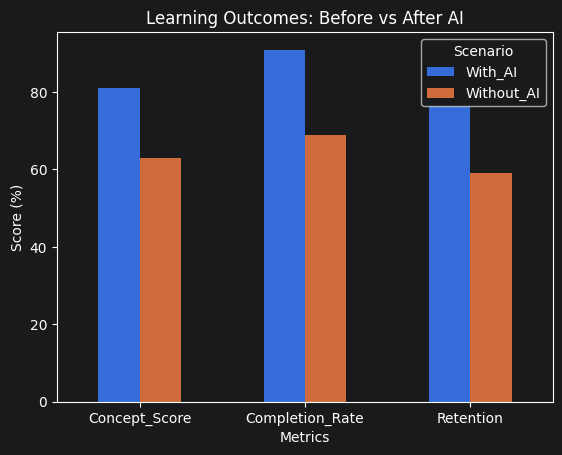

In [10]:
# 1. Learning Improvement Graph
plt.figure()
summary[["Concept_Score", "Completion_Rate", "Retention"]].T.plot(kind="bar")
plt.title("Learning Outcomes: Before vs After AI")
plt.ylabel("Score (%)")
plt.xlabel("Metrics")
plt.xticks(rotation=0)
plt.show()

<Figure size 640x480 with 0 Axes>

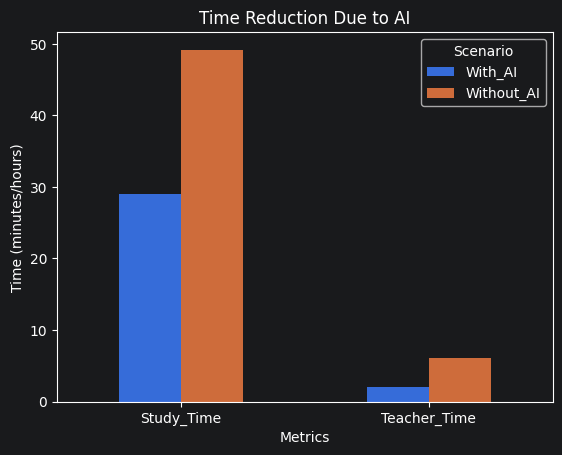

In [11]:
# 2. Time Reduction Graph
plt.figure()
summary[["Study_Time", "Teacher_Time"]].T.plot(kind="bar")
plt.title("Time Reduction Due to AI")
plt.ylabel("Time (minutes/hours)")
plt.xlabel("Metrics")
plt.xticks(rotation=0)
plt.show()

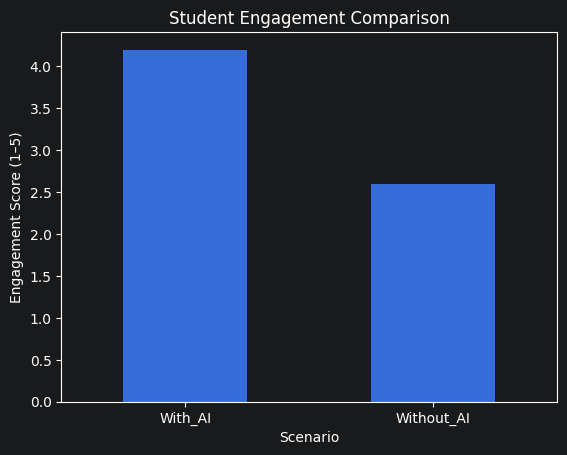

In [12]:
# 3. Engagement Improvement
plt.figure()
summary["Engagement"].plot(kind="bar")
plt.title("Student Engagement Comparison")
plt.ylabel("Engagement Score (1–5)")
plt.xticks(rotation=0)
plt.show()

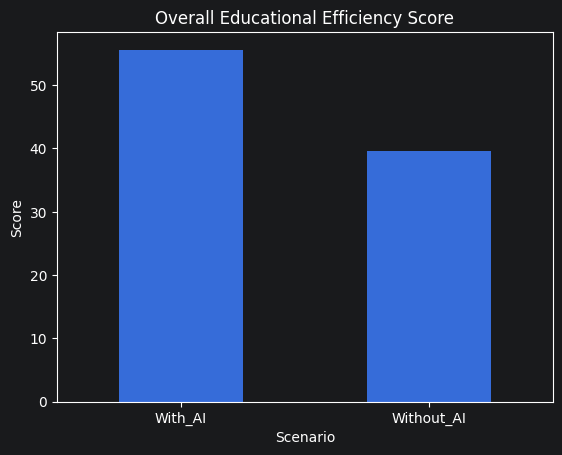

In [13]:
# 4. Efficiency Score Comparison
plt.figure()
summary["Efficiency_Score"].plot(kind="bar")
plt.title("Overall Educational Efficiency Score")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [14]:
if summary.loc["With_AI", "Efficiency_Score"] > summary.loc["Without_AI", "Efficiency_Score"]:
    print("\nAI significantly improves overall educational efficiency.")
else:
    print("\nAI shows limited impact.")
plt.show()


AI significantly improves overall educational efficiency.
